# **Analiza Interakcija finala Grand slemova 1976-2025**

In [1]:
from pathlib import Path
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import pickle

## **1.Učitvanje podataka**

Da bismo uspešno analizirali razvoj muškog tenisa i istorijska rivalstva u ovom projektu, prvo moramo učitati dataset 'grand_slam_winners.csv'. Ovaj set podataka sadrži imena finalista Grand Slam turnira, naziv turnira na kojem su se sastali, pobednika meča, kao i godinu odigravanja finala.

In [2]:
from google.colab import files
data_files=files.upload()
data=pd.read_csv('grand_slam_winers.csv')

Saving grand_slam_winers.csv to grand_slam_winers.csv


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   player_one  200 non-null    object
 1   player_two  200 non-null    object
 2   grand_slam  200 non-null    object
 3   winner      200 non-null    object
 4   year        200 non-null    int64 
dtypes: int64(1), object(4)
memory usage: 7.9+ KB


U našem datasetu imamo 200 iteracija, ne postoje null vrednosti, možemo krenuti sa analizom

Pomoću biblioteke **NetworkX** kreiramo prazan neusmereng graf X. Graf se sastoji od čvorova(**nodes**) što kod nas predstavlja tenisera i ivice(**edges**) što kod nas predstavlja susret u finalu Grand Slam turnira.

In [4]:
X=nx.Graph()

In [5]:
players=pd.unique(data[['player_one','player_two']].values.ravel())
print(players)

['Carlos Alcaraz' 'Novak Djokovic' 'Jannik Sinner' 'Daniil Medvedev'
 'Alexander Zverev' 'Taylor Fritz' 'Stefanos Tsitsipas' 'Casper Ruud'
 'Rafael Nadal' 'Nick Kyrgios' 'Matteo Berrettini' 'Dominic Thiem'
 'Roger Federer' 'Marin Cilic' 'Kevin Anderson' 'Juan Martin del Potro'
 'Stan Wawrinka' 'Andy Murray' 'Milos Raonic' 'Kei Nishikori'
 'David Ferrer' 'Robin Soderling' 'Tomas Berdych' 'Andy Roddick'
 'Jo-Wilfried Tsonga' 'Fernando Gonzalez' 'Marcos Baghdatis' 'Marat Safin'
 'Lleyton Hewitt' 'Mariano Puerta' 'Andre Agassi' 'Gaston Gaudio'
 'Guillermo Coria' 'Rainer Schuettler' 'Juan Carlos Ferrero'
 'Martin Verkerk' 'Mark Philippoussis' 'Thomas Johansson' 'Albert Costa'
 'David Nalbandian' 'Pete Sampras' 'Arnaud Clement' 'Gustavo Kuerten'
 'Alex Corretja' 'Goran Ivanisevic' 'Patrick Rafter' 'Magnus Norman'
 'Yevgeny Kafelnikov' 'Thomas Enqvist' 'Andrei Medvedev' 'Todd Martin'
 'Petr Korda' 'Marcelo Rios' 'Carlos Moya' 'Sergi Bruguera'
 'Cedric Pioline' 'Greg Rusedski' 'Boris Becker' '

Jedinstveni igrači su prikazani redom, od najskorijih finalista.

In [6]:
X.add_nodes_from(players)

Sada nam čvorovi predstavljaju igrače, ali da bi napravili graf potrebni su nam i edges.
Prolazimo kroz dataset tj kolone player_one i player_two i tako formiramo edge, svakim novim susretom edge dobija na težini što ćemo kasnije analizirati

In [7]:
for _, row in data.iterrows():
  p1=row['player_one']
  p2=row['player_two']
  if X.has_edge(p1,p2):
    X[p1][p2]['weight']+=1
  else:
    X.add_edge(p1,p2,weight=1)


In [8]:
print("Nodes:",X.nodes)
print("Edge with weight",X.edges(data=True))
print("Number of nodes",X.number_of_nodes())
print("Number of edges",X.number_of_edges())

Nodes: ['Carlos Alcaraz', 'Novak Djokovic', 'Jannik Sinner', 'Daniil Medvedev', 'Alexander Zverev', 'Taylor Fritz', 'Stefanos Tsitsipas', 'Casper Ruud', 'Rafael Nadal', 'Nick Kyrgios', 'Matteo Berrettini', 'Dominic Thiem', 'Roger Federer', 'Marin Cilic', 'Kevin Anderson', 'Juan Martin del Potro', 'Stan Wawrinka', 'Andy Murray', 'Milos Raonic', 'Kei Nishikori', 'David Ferrer', 'Robin Soderling', 'Tomas Berdych', 'Andy Roddick', 'Jo-Wilfried Tsonga', 'Fernando Gonzalez', 'Marcos Baghdatis', 'Marat Safin', 'Lleyton Hewitt', 'Mariano Puerta', 'Andre Agassi', 'Gaston Gaudio', 'Guillermo Coria', 'Rainer Schuettler', 'Juan Carlos Ferrero', 'Martin Verkerk', 'Mark Philippoussis', 'Thomas Johansson', 'Albert Costa', 'David Nalbandian', 'Pete Sampras', 'Arnaud Clement', 'Gustavo Kuerten', 'Alex Corretja', 'Goran Ivanisevic', 'Patrick Rafter', 'Magnus Norman', 'Yevgeny Kafelnikov', 'Thomas Enqvist', 'Andrei Medvedev', 'Todd Martin', 'Petr Korda', 'Marcelo Rios', 'Carlos Moya', 'Sergi Bruguera', '

Možemo videti da je broj čvorova 96, ali broj grana 128, ovo je relativno mali broj grana za ovoliku mrežu, što nam govori da u poslednjih 50 godina bila dominacaija nekoliko igrača.

# **2. Vizuelizacija i stilizacija mreže**
U ovoj fazi fokus stavljamo na vizuelnu reprezentaciju grafa kako bismo dobili jasniji uvid u strukturu rivalstava. Ključni parametar koji koristimo je ponderisani stepen čvora (weighted degree). Za svakog tenisera u mreži izračunata je ukupna težina svih njegovih grana, što u našem kontekstu direktno predstavlja ukupan broj odigranih finala tog igrača sa svim protivnicima u bazi.

In [9]:
weighted_degree = dict(X.degree(weight='weight'))
node_sizes = [weighted_degree[player] * 75 + 500 for player in X.nodes()]
node_colors = [weighted_degree[player] for player in X.nodes()]

Sledeci korak jeste crtanje grafika, koje mozemo odraditi na nekoliko nacina i to:


*   spring_layout(Fruchterman-Reingold algorithm): tretiranje veze između igrača kao "opruge".
*   kamada_kawai_layout: Ovaj model pokušava da razmak između čvorova na ekranu uskladi sa njihovom stvarnom distancom u podacima
*   circular_layout: postavlja tenisere u nasem slucaju u krug,ali zbog velicine uzorka doslo bi do preklapanja


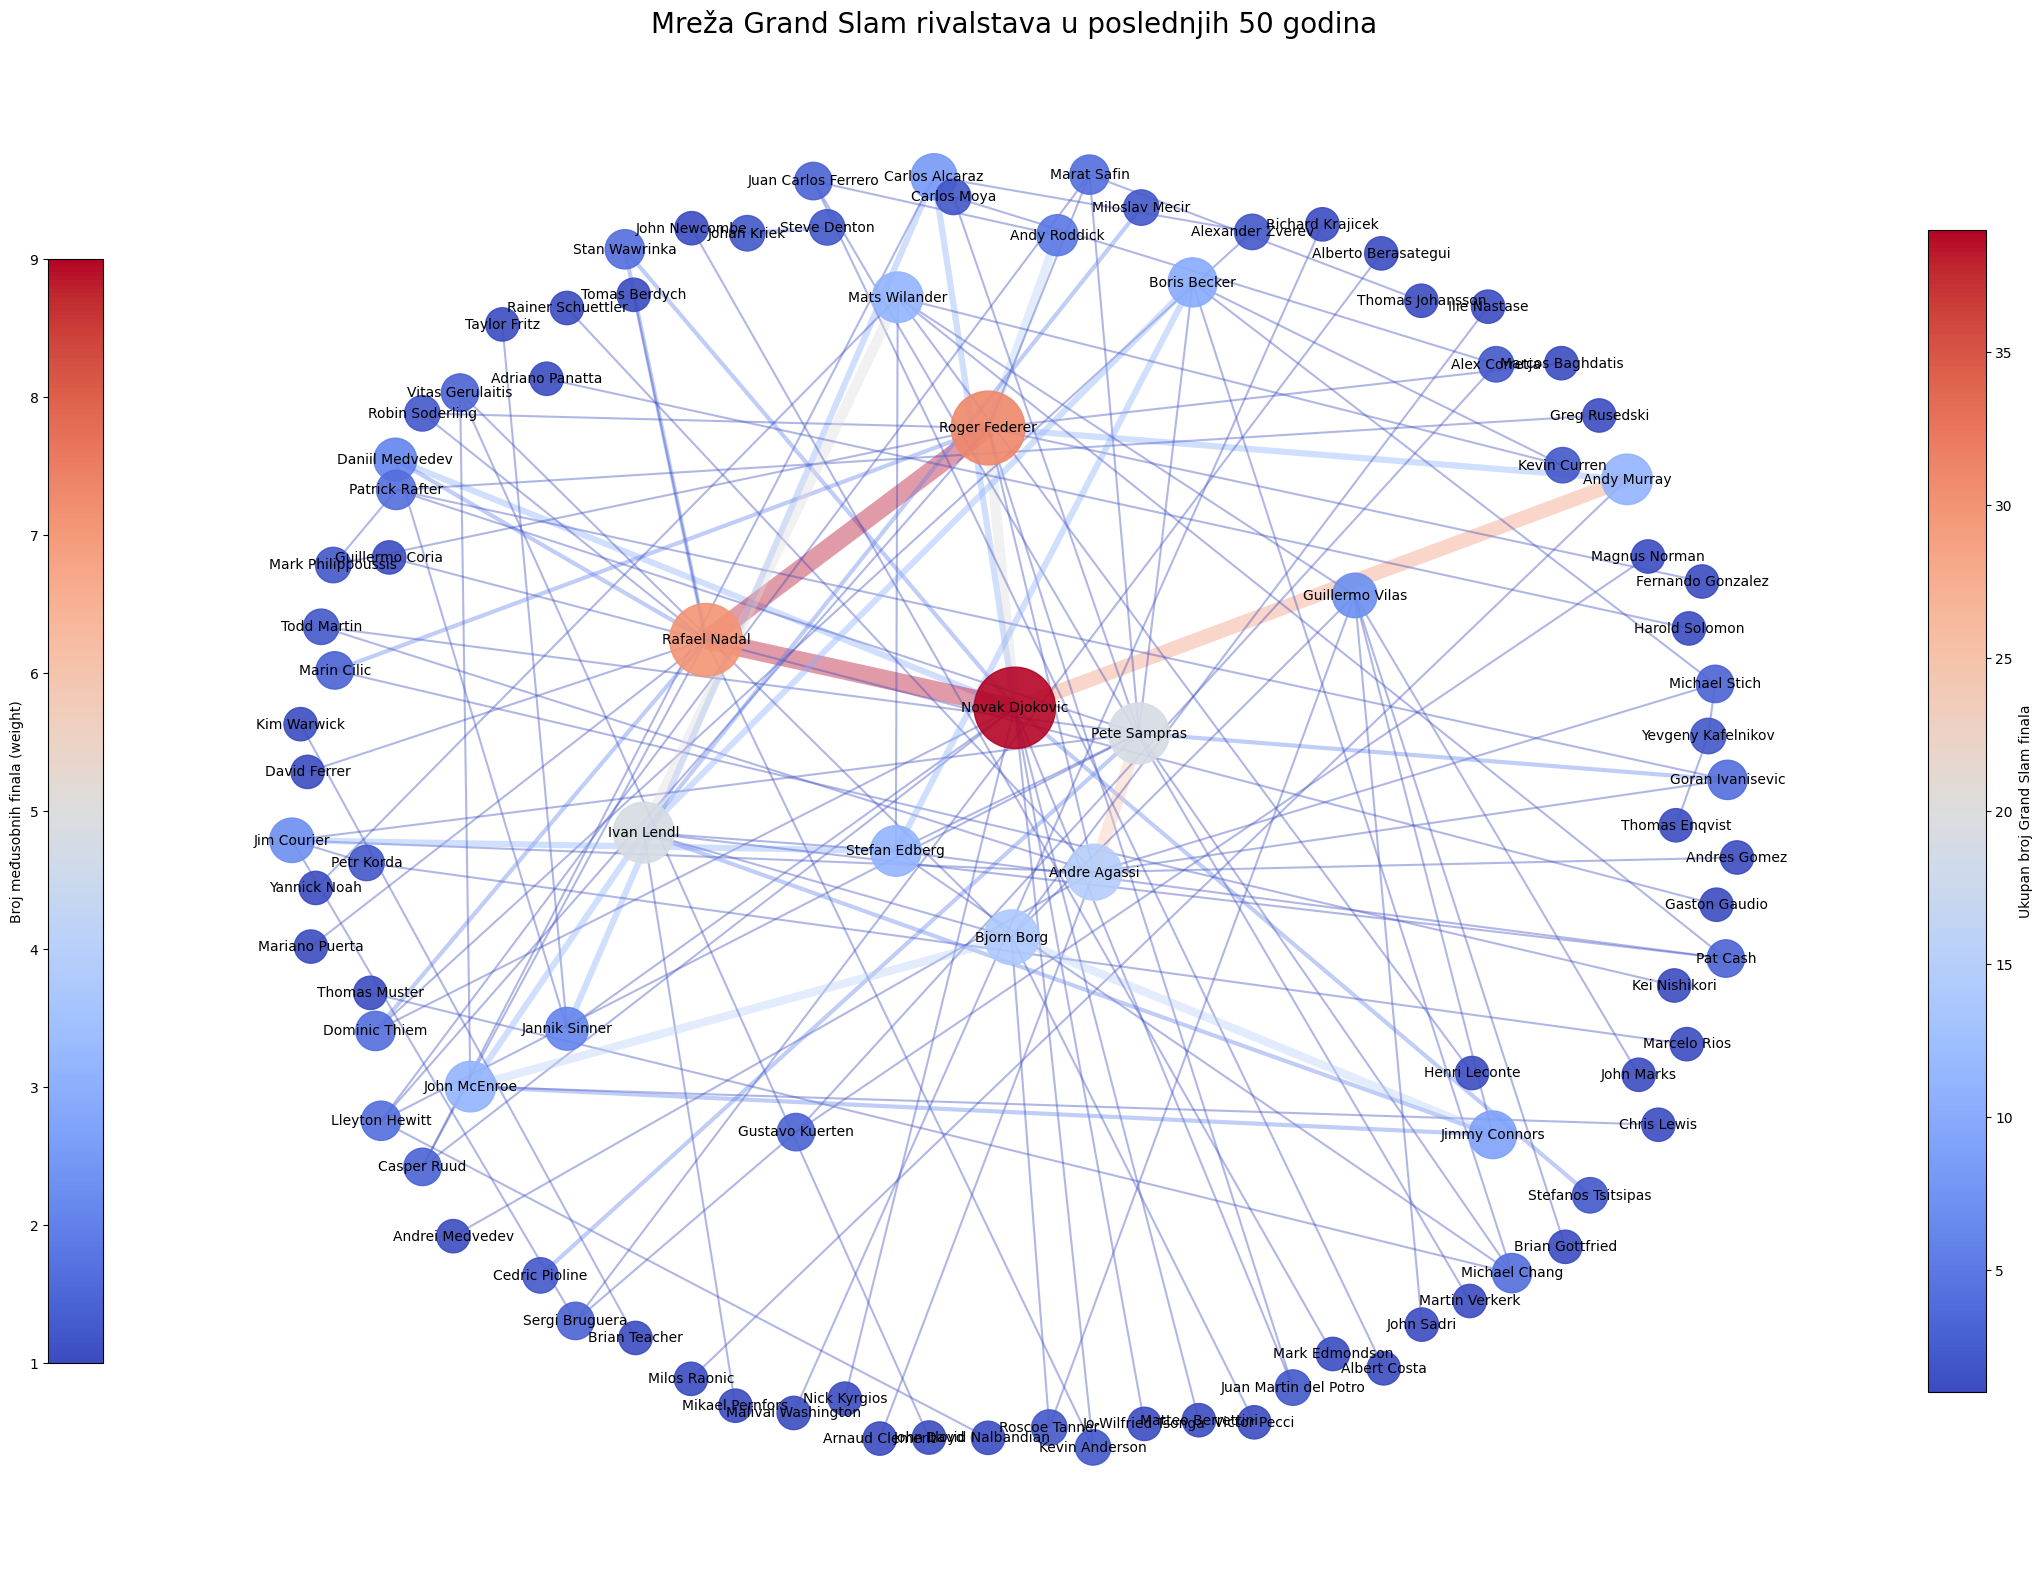

In [10]:
plt.figure(figsize=(25,20))
ax = plt.gca()

pos = nx.spring_layout(X, k=3, iterations=100, weight='weight', seed=42)

edge_weights = [d['weight'] for (u, v, d) in X.edges(data=True)]
edge_widths = [w * 1.5 for w in edge_weights]

nx.draw_networkx_nodes(X, pos, node_size=node_sizes, node_color=node_colors,cmap=plt.cm.coolwarm, alpha=0.9)

nx.draw_networkx_edges(X, pos, width=edge_widths,edge_color=edge_weights, edge_cmap=plt.cm.coolwarm, alpha=0.4)

nx.draw_networkx_labels(X, pos, font_size=10, font_family='sans-serif')

sm = plt.cm.ScalarMappable(cmap=plt.cm.coolwarm,norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors)))
plt.colorbar(sm, ax=ax, label="Ukupan broj Grand Slam finala", fraction=0.03, pad=0.02)

sm_edges = plt.cm.ScalarMappable(cmap=plt.cm.coolwarm,norm=plt.Normalize(vmin=min(edge_weights), vmax=max(edge_weights)))
plt.colorbar(sm_edges, ax=ax, label="Broj međusobnih finala (weight)", location='left', fraction=0.03, pad=0.02)

plt.title("Mreža Grand Slam rivalstava u poslednjih 50 godina", fontsize=20)
plt.axis('off')
plt.show()

Na samom grafiku možemo uočiti da teniseri sa par finala formiraju krug,dok se u tom krugu nalaze legende tenisa sa 10+ finala(Bjorn Borg,Ande Agassi,Pete Sampras,Rafael Nadal) i može se uočiti da je najbolji teniser svih vremena,Novak Đoković u sredini grafa sa odigranih 38 finala-dominacija.

Najčešće veze možemo uočiti između Novaka Đokovića, Rafaela Nadala i Rogera Federera(Big 3) koji su dominirali u periodu 2010-2019.Tom periodu samo par tenisera je moglo da poremeti dominaciju velike trojke, jedan od njih je Andy Murray.Iako po težini grafa(svetlo plava) ima čak 11 finala,od kojih je 3 dobio,što je za taj period skoro pa nemoguće.
Iako se na grafiku interakcija između Carlosa Alcaraza i Jannika Sinnera još uvek vidi kao relativno tanka veza na periferiji centra, ona predstavlja najznačajniji indikator smene generacija. Zbog kumulativne prirode grafa koji obuhvata poslednjih 50 godina, njihov trenutni 'weight' (težina veze) ne može odmah parirati decenijskim rivalstvima Velike trojke, ali njihova pozicija sugeriše da će u budućim analizama upravo ova grana postati nova centralna osa mreže.



# **3.Opis Prikupljenih Podataka**

Koristićemo nekoliko različitih metoda za opis interakcija tenisera.

In [11]:
gustina = nx.density(X)
print(f"Gustina mreže: {gustina:.4f}")

Gustina mreže: 0.0281


Gustina mreže od 0.0281 znači da je ostvareno samo oko 2.81% od svih mogućih veza između igrača.Drugim rečima, većina igrača se nije sretala u Grand Slam finalima što je i logično, jer samo najbolji igrači dosežu finale, a dominacija nekolicine (Đoković, Federer, Nadal) čini mrežu retkom i centralizovanom.

In [12]:
components = list(nx.connected_components(X))
number_of_components = nx.number_connected_components(X)
largest_component_size = len(max(components, key=len))

print("Broj povezanih komponenti:", number_of_components)
print("Velicina najvece komponente:", largest_component_size)

for i, comp in enumerate(sorted(components, key=len, reverse=True)):
    print(f"Komponenta {i+1}: {len(comp)} igrača - {comp}")


Broj povezanih komponenti: 7
Velicina najvece komponente: 84
Komponenta 1: 84 igrača - {'Vitas Gerulaitis', 'Cedric Pioline', 'Goran Ivanisevic', 'Carlos Alcaraz', 'Jim Courier', 'Marin Cilic', 'Patrick Rafter', 'Roger Federer', 'Petr Korda', 'Rafael Nadal', 'Thomas Johansson', 'Ilie Nastase', 'Dominic Thiem', 'David Nalbandian', 'Carlos Moya', 'Henri Leconte', 'Magnus Norman', 'Andy Murray', 'Andres Gomez', 'Thomas Enqvist', 'Martin Verkerk', 'Stefan Edberg', 'Kei Nishikori', 'Bjorn Borg', 'Greg Rusedski', 'Andy Roddick', 'Michael Stich', 'Albert Costa', 'Arnaud Clement', 'Pat Cash', 'Alberto Berasategui', 'Jannik Sinner', 'Tomas Berdych', 'Yevgeny Kafelnikov', 'Andrei Medvedev', 'Fernando Gonzalez', 'Guillermo Vilas', 'Mariano Puerta', 'John Sadri', 'John Marks', 'Gustavo Kuerten', 'Marcelo Rios', 'Juan Martin del Potro', 'Milos Raonic', 'Alex Corretja', 'Lleyton Hewitt', 'Andre Agassi', 'Victor Pecci', 'David Ferrer', 'Thomas Muster', 'Sergi Bruguera', 'Alexander Zverev', 'Daniil Me

Mreža sadrži 7 povezanih komponenti. Najveća komponenta broji 84 igrača i obuhvata sve velike zvezde moderne i klasične ere tenisa – od Borga i McEnroea do Đokovića i Alcaraza. Ovih 84 igrača su međusobno posredno ili direktno povezani kroz finala.
Preostalih 6 komponenti su izolovani parovi igrača koji su se sreli u samo jednom finalu međusobno, bez ikakve druge veze sa ostatkom mreže. Na primer, Gaudio i Coria su odigrali finale Roland Garrosa 2004. godine, ali nikad nisu igrali finale protiv nekog iz glavne grupe. Isto važi za Krajiceka i Washingtona (Wimbledon 1996), kao i za ostale izolovane parove koji su imali kratke ili specifične karijere.
Ova struktura je očekivana – igrači koji su dostigli samo jedno finale u karijeri i nisu se više vraćali na taj nivo prirodno ostaju izolovani od centralne mreže.

**3.1 Raspodela stepena čvorova**

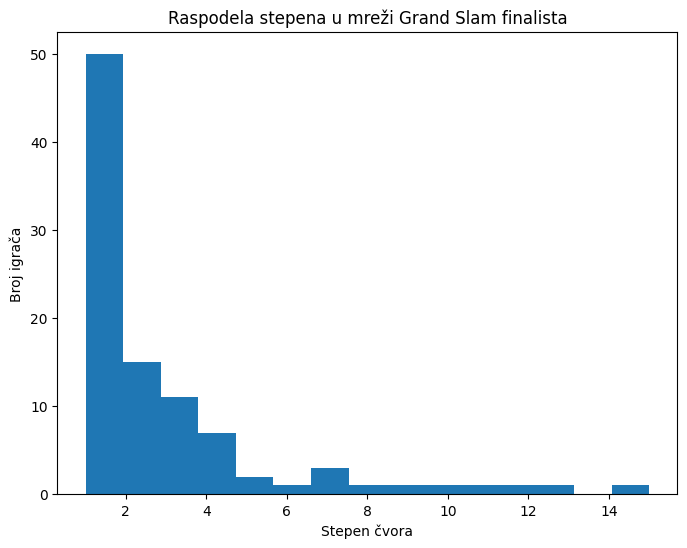

Prosečan stepen: 2.6666666666666665
Medijana: 1.0


In [13]:
import numpy as np

degree_values = [d for _, d in X.degree()]

plt.figure(figsize=(8,6))
plt.hist(degree_values, bins=15)
plt.xlabel("Stepen čvora")
plt.ylabel("Broj igrača")
plt.title("Raspodela stepena u mreži Grand Slam finalista")
plt.show()

print("Prosečan stepen:", sum(degree_values)/len(degree_values))
print("Medijana:", np.median(degree_values))

Analiziranjem raspodele stepena čvorova dobijamo heterogenu mrežu sa izrazitom asimetrijom. Najveći broj igrača (oko 50) ima stepen 1, što znači da su igrali finale samo protiv jednog protivnika u karijeri. Nakon toga sledi nagli pad – sve manji broj igrača ima veći broj finalnih protivnika.
Prosečan stepen iznosi 2.67, dok je medijana samo 1.0, što jasno ukazuje na asimetričnost raspodele – većina igrača je jednokratni finalisti, dok mali broj igrača (hub-ovi poput Đokovića, Federera, Nadala) ima stepen i do 15, što ih čini ključnim čvorovima mreže. Ovakav oblik raspodele sa "teškim repom" (heavy tail) karakterističan je za scale-free mreže.

**3.2 Dijametar i prosečna dužina puta**

In [14]:
largest_component = max(nx.connected_components(X), key=len)
X_main = X.subgraph(largest_component)

diameter = nx.diameter(X_main)
avg_path = nx.average_shortest_path_length(X_main)

print("Dijametar grafa:", diameter)
print("Prosečna dužina puta:", avg_path)

Dijametar grafa: 10
Prosečna dužina puta: 4.411072862880092


Dijametar mreže iznosi 10, što znači da su najudaljeniji igrači u mreži međusobno udaljeni 10 koraka. Da bismo ovo lakše razumeli – zamislimo da tražimo vezu između nekog igrača iz 1970-ih i Novaka Đokovića. Oni nikad nisu direktno igrali jedno protiv drugog, ali su povezani kroz lanac međusobnih finalnih rivalstava – recimo Newcombe je igrao protiv Connorsa, Connors protiv Lendla, Lendl protiv Agassija, Agassi protiv Federera, Federer protiv Đokovića. Pet koraka i dva igrača iz potpuno različitih era su povezana.
Ova visoka vrednost dijametra direktna je posledica vremenskog raspona podataka od 50 godina – igrači iz različitih era fizički nisu mogli da se sretnu u finalima, pa su veze između njih nužno dugačke i indirektne.
Prosečna dužina puta od 4.41 govori da su u proseku bilo koja dva igrača u mreži međusobno udaljena oko 4 do 5 koraka. Ovo je relativno visoka vrednost koja potvrđuje da mreža nema izražene "small-world" osobine – za razliku od društvenih mreža gde svako poznaje svakoga kroz mali broj veza, u tenisu finale je privilegija malog broja igrača i veze između njih su retke i specifične.

In [15]:
avg_clustering = nx.average_clustering(X)
print("Prosečni klastering koeficijent:", avg_clustering)

Prosečni klastering koeficijent: 0.15687790219040218


Prosečni koeficijent klasterovanja iznosi 0.157, što je relativno niska vrednost. Ovo znači da susedi nekog igrača u mreži međusobno retko igraju finala jedni protiv drugih – odnosno samo oko 15% mogućih veza između suseda jednog igrača zaista postoji.

**Degree Centrality**






Na osnovu Degree Centrality analize, Novak Đoković (0.158) ima najveći broj različitih finalnih protivnika u mreži, što ga čini centralnim čvorištem koje povezuje različite generacije igrača. Slede Federer (0.137) i Sampras (0.126), što potvrđuje da su sva trojica ključni mostovi između različitih era Grand Slam tenisa.

In [16]:
tennis_degree_cent = nx.degree_centrality(X)
sorted_degree = sorted(tennis_degree_cent.items(), key=lambda x: x[1], reverse=True)
print("Top 5 tenisera po stepenu centralnosti: ", sorted_degree[:5])

Top 5 tenisera po stepenu centralnosti:  [('Novak Djokovic', 0.15789473684210525), ('Roger Federer', 0.1368421052631579), ('Pete Sampras', 0.12631578947368421), ('Rafael Nadal', 0.11578947368421053), ('Andre Agassi', 0.10526315789473684)]


**Betweenness centrality**

Betweenness centrality meri koliko puta se određeni igrač nalazi na najkraćem putu između ostalih igrača u mreži – odnosno ko služi kao "most" koji povezuje različite grupe. Roger Federer (0.420) zauzima prvo mesto, što potvrđuje njegovu jedinstvenu ulogu premošćavanja različitih era – igrao je i protiv igrača starije generacije poput Samprasa i Agassija, ali i protiv mlađe generacije poput Đokovića i Nadala. Sampras (0.352) i Edberg (0.264) slede, jer oba igrača predstavljaju ključne karike između starije i moderne ere tenisa. Đoković je na četvrtom mestu što je iznenađujuće, ali ima smisla – njegova dominacija je koncentrisana u modernoj eri gde se rivalstva preklapaju, dok Federer pokriva širi vremenski raspon.

In [17]:
betweenness_centrality = nx.betweenness_centrality(X, normalized=True, weight='weight')
sorted_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)
print("Top 5 tenisera po centralnosti posrednistva: ", sorted_betweenness[:5])

Top 5 tenisera po centralnosti posrednistva:  [('Roger Federer', 0.4198208286674132), ('Pete Sampras', 0.3524449421425907), ('Stefan Edberg', 0.26360582306830915), ('Novak Djokovic', 0.17443075774542738), ('Andre Agassi', 0.17256438969764842)]


**Closeness Centrality**

Closeness centrality meri koliko je jedan igrač u proseku blizu svim ostalim igračima u mreži – što je vrednost veća, igrač je centralniji i "bliži" celoj mreži.

In [18]:
closeness_centrality = nx.closeness_centrality(X)
sorted_closeness = sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)
print("Top 5 tenisera po blizinskoj centralnosti:", sorted_closeness[:5])

pd.Series(closeness_centrality.values()).describe()

Top 5 tenisera po blizinskoj centralnosti: [('Andre Agassi', 0.30214912280701756), ('Pete Sampras', 0.2971958584987058), ('Roger Federer', 0.29006315789473686), ('Jim Courier', 0.28549523414836303), ('Marat Safin', 0.27998374314163793)]


,0
count,96.000000
mean,0.180467
std,0.073810
min,0.010526
25%,0.159378
50%,0.190581
75%,0.225204
max,0.302149


Na prvom mestu nalazi se Andre Agassi (0.302), što je iznenađujuće na prvi pogled, ali ima smisla kada se uzme u obzir njegova karijera – Agassi je bio aktivan od kasnih 1980-ih do 2006. godine, što znači da je igrao finala i protiv starijih igrača poput Connorsa i Lendla, ali i protiv mlađe generacije poput Federera i Roddika. Ta "premošćujuća" pozicija između era čini ga centralnim čvorom.
Sampras (0.297) i Federer (0.290) slede, što je očekivano s obzirom na njihovu dominaciju tokom dugih perioda i veliki broj različitih finalnih protivnika

**Eigenvector Centrality**

Eigenvector centrality meri važnost čvora ne samo kroz broj njegovih veza, već i kroz važnost samih suseda – odnosno, igrač je važniji ako je igrao finala protiv drugih važnih igrača. Za razliku od degree centrality koja broji samo broj različitih protivnika, eigenvector centrality nagrađuje one koji su se borili protiv najjačih.

In [19]:
eigen_centrality = nx.eigenvector_centrality(X, max_iter=1000, weight='weight')
sorted_eigen = sorted(eigen_centrality.items(), key=lambda x: x[1], reverse=True)
print("Top 5 tenisera po eigen centralnosti:", sorted_eigen[:5])

Top 5 tenisera po eigen centralnosti: [('Novak Djokovic', 0.5565508482599287), ('Rafael Nadal', 0.5366483586879938), ('Roger Federer', 0.4810864867270255), ('Andy Murray', 0.27931856457213033), ('Daniil Medvedev', 0.1458339977946747)]


Na osnovu Eigenvector centrality analize, Novak Đoković (0.557) zauzima prvo mesto, što potvrđuje da nije samo igrao finala protiv velikog broja protivnika, već protiv najvažnijih i najdominantnijih igrača ere. Nadal (0.537) i Federer (0.481) slede odmah iza, što je i očekivano s obzirom da su sva trojica međusobno igrala brojna finala – čineći tzv. "Veliku trojku" koja se uzajamno pojačava po ovoj metrici.
Andy Murray (0.279) je na četvrtom mestu, što ima smisla jer je veliki deo svoje karijere proveo igrajući finala upravo protiv Đokovića, Federera i Nadala – najvažnijih čvorova u mreži. Medvedev (0.146) je na petom mestu kao predstavnik nove generacije koja je tek počela da gradi rivalstva sa dominantnim igračima.
Zanimljivo je da igrači poput Agassija i Samprasa, koji su visoko rangirani po closeness centrality, ovde opadaju, jer su njihovi protivnici iz starije ere manje važni čvorovi u ukupnoj mreži.

**Louvain detekcija zajednica**

Louvain algoritam je metoda za detekciju zajednica u mreži koja grupiše čvorove koji međusobno imaju više veza nego sa ostatkom mreže. U kontekstu našeg projekta, algoritam grupiše igrače koji su češće igrali finala jedni protiv drugih, bez ikakvog predznanja o godinama ili podlogama.

In [20]:
from networkx.algorithms.community import louvain_communities

communities = louvain_communities(X, weight='weight', seed=42)
community_map = {}
for i, community in enumerate(communities):
    print(f"Zajednica {i+1}: ", community)
    for node in community:
        community_map[node] = i

Zajednica 1:  {'Alexander Zverev', 'Daniil Medvedev', 'Taylor Fritz', 'Mariano Puerta', 'Rafael Nadal', 'Jannik Sinner', 'Carlos Alcaraz', 'Tomas Berdych', 'Robin Soderling', 'Marin Cilic', 'Novak Djokovic', 'Dominic Thiem', 'Kei Nishikori', 'Juan Martin del Potro', 'Milos Raonic', 'Andy Roddick', 'Matteo Berrettini', 'Stefanos Tsitsipas', 'Nick Kyrgios', 'Fernando Gonzalez', 'Roger Federer', 'Kevin Anderson', 'David Ferrer', 'Stan Wawrinka', 'Jo-Wilfried Tsonga', 'Marcos Baghdatis', 'Casper Ruud', 'Andy Murray'}
Zajednica 2:  {'Todd Martin', 'Cedric Pioline', 'Rainer Schuettler', 'Goran Ivanisevic', 'Pete Sampras', 'Andres Gomez', 'Thomas Johansson', 'Thomas Enqvist', 'Yevgeny Kafelnikov', 'Marat Safin', 'Patrick Rafter', 'Mark Philippoussis', 'Greg Rusedski', 'Lleyton Hewitt', 'Michael Stich', 'Andrei Medvedev', 'Andre Agassi', 'David Nalbandian', 'Arnaud Clement'}
Zajednica 3:  {'Guillermo Coria', 'Gaston Gaudio'}
Zajednica 4:  {'Juan Carlos Ferrero', 'Martin Verkerk', 'Albert Costa

Louvain algoritam identifikovao je 12 zajednica, od kojih 6 manjih predstavljaju izolovane parove koje smo već videli u analizi connected components. Zanimljivije su veće zajednice koje jasno oslikavaju različite ere Grand Slam tenisa.
Zajednica 1 je najveća i obuhvata modernu eru tenisa – od Federera, Nadala i Đokovića do najmlađe generacije poput Sinera i Alcaraza. Ovo je era koja traje od ranih 2000-ih do danas i karakteriše je dominacija "Velike trojke" uz postepeno uključivanje nove generacije.
Zajednica 2 predstavlja prelaznu eru 1990-ih i ranih 2000-ih, sa igračima poput Samprasa, Agassija, Ivanišević i Hewitt-a. Ovo je period između klasične i moderne ere, što algoritam ispravno prepoznaje kao zasebnu grupu.
Zajednice 4 i 5 su zanimljive jer grupišu isključivo šljakare – Ferrero, Costa, Kuerten, Bruguera, Moya – igrači koji su dominirali na Roland Garrosu tokom 1990-ih i ranih 2000-ih, ali retko osvajali ostale slemove.
Zajednica 7 obuhvata eru 1980-ih sa Lendlom, Beckerom, Edbergom i Willanderom, dok Zajednica 8 predstavlja najstariju eru iz 1970-ih sa Borgom, McEnroeom i Connorsom.

In [21]:
from networkx.algorithms.community.quality import modularity

mod = modularity(X, communities, weight='weight')
print("Modularnost:", mod)



Modularnost: 0.63255


Modularnost od 0.633 ukazuje na jasno definisane zajednice unutar mreže, što znači da igrači unutar iste ere imaju znatno više međusobnih finalnih rivalstava nego sa igračima iz drugih era. Ova vrednost potvrđuje da Louvain algoritam uspešno identifikuje prirodnu podelu teniske istorije na različite generacije.